# Tarefa 11 — Variáveis Aleatórias e Modelos de Probabilidade Aplicados às Ciências dos Alimentos

**Disciplina:** Probabilidade aplicada às Ciências dos Alimentos

**Objetivo:** apresentar e exemplificar, por meio de um script em Python, os conceitos introdutórios de
variável aleatória, variáveis discretas e contínuas, e os modelos de Bernoulli, Binomial e Poisson,
com exemplos aplicados a produção, processamento, controle de qualidade, análise sensorial,
segurança de alimentos, armazenamento e comercialização de produtos alimentícios.

Este notebook está organizado nas seguintes seções:

1. Variável aleatória
2. Variáveis discretas e contínuas
3. Modelo de Bernoulli
4. Modelo Binomial
5. Modelo de Poisson
6. Comparação entre os modelos
7. Referências


In [ ]:
# Bibliotecas utilizadas no trabalho
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Semente fixa para que os exemplos simulados sejam reprodutíveis
np.random.seed(42)

plt.rcParams["figure.figsize"] = (7, 4)
print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


## 1. Variável aleatória

Uma **variável aleatória** é uma função que associa a cada resultado possível de um **experimento
aleatório** (um processo cujo resultado não pode ser previsto com certeza, mas cujos possíveis
resultados são conhecidos) um número real. Ela permite traduzir resultados qualitativos ou
quantitativos de um experimento em valores numéricos que podem ser estudados estatisticamente
(MAGALHÃES; LIMA, 2015; ROSS, 2010).

Formalmente, se $\Omega$ é o espaço amostral de um experimento aleatório, uma variável aleatória
$X$ é uma função $X: \Omega \rightarrow \mathbb{R}$ que atribui um número real $X(\omega)$ a cada
resultado $\omega \in \Omega$.

**Exemplo aplicado às Ciências dos Alimentos:**
Considere o experimento aleatório "selecionar uma caixa com 20 frutas de um lote de exportação e
inspecionar cada fruta quanto à presença de dano visível (batida, corte ou início de podridão)".
O espaço amostral é o conjunto de todas as combinações possíveis de frutas danificadas/não
danificadas na caixa. Definimos a variável aleatória:

$$X = \text{número de frutas danificadas encontradas na caixa}$$

$X$ pode assumir os valores $0, 1, 2, \dots, 20$. Abaixo simulamos a inspeção de uma caixa.


In [ ]:
# Exemplo de variável aleatória: número de frutas danificadas em uma caixa de 20 unidades
# Dado simulado: cada fruta tem, de forma independente, 8% de chance de estar danificada
# (valor ilustrativo, coerente com taxas de perda pós-colheita relatadas na literatura de
# pós-colheita de frutas, tipicamente na faixa de 5-15%).

n_frutas = 20
prob_dano = 0.08

caixa = np.random.binomial(1, prob_dano, size=n_frutas)  # 1 = danificada, 0 = íntegra
X = caixa.sum()

print("Resultado da inspeção (1 = danificada, 0 = íntegra):")
print(caixa)
print(f"\nValor observado da variável aleatória X (nº de frutas danificadas na caixa): {X}")

Resultado da inspeção (1 = danificada, 0 = íntegra):
[0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]

Valor observado da variável aleatória X (nº de frutas danificadas na caixa): 2


## 2. Variáveis aleatórias discretas e contínuas

- Uma variável aleatória é **discreta** quando assume um número finito ou infinito **contável** de
  valores — geralmente resultado de uma **contagem** (MONTGOMERY; RUNGER, 2018).
- Uma variável aleatória é **contínua** quando pode assumir **qualquer valor dentro de um intervalo**
  (infinitos valores não contáveis) — geralmente resultado de uma **medição** (MONTGOMERY; RUNGER, 2018).

### Exemplos discretos (Ciências dos Alimentos)

| Variável | Justificativa da classificação |
|---|---|
| Número de embalagens reprovadas em um lote de inspeção | Resulta de uma contagem de itens (0, 1, 2, ...); não existem valores intermediários. |
| Número de reclamações de consumidores recebidas por dia sobre um produto | É uma contagem de eventos ao longo do tempo; assume apenas valores inteiros não negativos. |
| Número de colônias de bactérias contadas em uma placa de Petri | Resulta da contagem de unidades formadoras de colônia (UFC); valor sempre inteiro. |

### Exemplos contínuos (Ciências dos Alimentos)

| Variável | Justificativa da classificação |
|---|---|
| Massa (g) de um pacote de biscoitos na linha de envase | Pode assumir qualquer valor real dentro de um intervalo (ex.: 198,3 g; 198,37 g...), limitado pela precisão do instrumento. |
| Temperatura (°C) de uma câmara fria de armazenamento | Varia continuamente no tempo e pode assumir qualquer valor real dentro da faixa operacional. |
| Teor de umidade (%) de um lote de grãos | É uma medição física que pode assumir infinitos valores dentro de um intervalo (ex.: 12,4%; 12,45%...). |

A seguir, ilustramos numericamente essa diferença: geramos uma variável discreta (contagem) e uma
variável contínua (medição) e comparamos seus valores possíveis.


In [ ]:
# Ilustração numérica: discreta x contínua

# Discreta: número de embalagens reprovadas em uma amostra de 15 embalagens (contagem)
reprovadas = np.random.binomial(1, 0.1, size=15)
n_reprovadas = reprovadas.sum()
print("Variável DISCRETA — nº de embalagens reprovadas na amostra:", n_reprovadas)
print("Valores possíveis: {0, 1, 2, ..., 15} -> conjunto contável\n")

# Contínua: massa (g) de embalagens de um produto, com média 200 g e desvio-padrão 2 g
massas = np.random.normal(loc=200, scale=2, size=15)
print("Variável CONTÍNUA — massas (g) de 15 embalagens amostradas:")
print(np.round(massas, 3))
print("\nValores possíveis: qualquer número real dentro de um intervalo -> conjunto não contável")

Variável DISCRETA — nº de embalagens reprovadas na amostra: 2
Valores possíveis: {0, 1, 2, ..., 15} -> conjunto contável

Variável CONTÍNUA — massas (g) de 15 embalagens amostradas:
[198.799 201.895 200.582 198.729 197.957 199.676 198.933 199.989 199.541
 200.779 197.47  202.184 205.557 202.387 200.437]

Valores possíveis: qualquer número real dentro de um intervalo -> conjunto não contável


## 3. Modelo de Bernoulli

O modelo de **Bernoulli** descreve um experimento aleatório com **apenas dois resultados possíveis**:
sucesso (valor 1) e fracasso (valor 0), com probabilidade de sucesso $p$ constante (ROSS, 2010).

$$P(X = 1) = p \qquad P(X = 0) = 1-p$$

**Exemplo aplicado:** uma embalagem de alimento, ao ser inspecionada quanto à qualidade da selagem,
é classificada como **aprovada** (sucesso) ou **reprovada** (fracasso).

Segundo o padrão internacional de amostragem de aceitação **ISO 2859-1**, é comum adotar um
**Nível de Qualidade Aceitável (AQL)** de **2,5%** para defeitos maiores em lotes de produtos —
ou seja, tolera-se, em média, até 2,5% de itens defeituosos (GUELCOS, 2023; ISIXSIGMA, 2023).
Usamos esse parâmetro de referência para definir a probabilidade de reprovação no exemplo:
$p(\text{reprovada}) = 0,025$, logo $p(\text{aprovada}) = 0,975$.

- **Sucesso (1):** embalagem aprovada quanto à selagem.
- **Fracasso (0):** embalagem reprovada quanto à selagem.


In [ ]:
# Modelo de Bernoulli: inspeção da selagem de UMA embalagem
p_aprovada = 0.975  # probabilidade de sucesso (embalagem aprovada), baseada em AQL de 2,5% (ISO 2859-1)

bernoulli_rv = stats.bernoulli(p_aprovada)

# Uma única observação (um único experimento de Bernoulli)
resultado = bernoulli_rv.rvs(size=1, random_state=42)[0]
status = "APROVADA" if resultado == 1 else "REPROVADA"

print(f"Probabilidade de sucesso (embalagem aprovada): p = {p_aprovada}")
print(f"Probabilidade de fracasso (embalagem reprovada): 1-p = {1 - p_aprovada:.3f}")
print(f"\nResultado da inspeção de uma embalagem: X = {resultado} -> {status}")

print(f"\nMédia teórica E[X] = p = {bernoulli_rv.mean():.3f}")
print(f"Variância teórica Var[X] = p(1-p) = {bernoulli_rv.var():.5f}")

Probabilidade de sucesso (embalagem aprovada): p = 0.975
Probabilidade de fracasso (embalagem reprovada): 1-p = 0.025

Resultado da inspeção de uma embalagem: X = 1 -> APROVADA

Média teórica E[X] = p = 0.975
Variância teórica Var[X] = p(1-p) = 0.02438


**Interpretação:** como $p = 0,975$ é próximo de 1, o resultado esperado é que, na grande
maioria das inspeções, a embalagem seja aprovada. O valor esperado $E[X] = p = 0,975$ pode ser lido
como "a proporção esperada de embalagens aprovadas em um número grande de inspeções repetidas",
o que é coerente com um processo de selagem sob controle de qualidade.

## 4. Modelo Binomial

O modelo **Binomial** representa o **número de sucessos** em um **número fixo $n$ de observações
(ensaios de Bernoulli independentes)**, cada uma com a mesma probabilidade de sucesso $p$
(MONTGOMERY; RUNGER, 2018).

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \qquad k = 0, 1, \dots, n$$

Condições necessárias:
- número fixo de observações ($n$);
- cada observação tem apenas dois resultados possíveis (sucesso/fracasso);
- probabilidade de sucesso ($p$) constante e observações independentes entre si.

**Exemplo aplicado:** em um lote de embalagens, uma amostra de **n = 50 embalagens** é inspecionada
quanto à selagem. Definimos:

$$X = \text{número de embalagens REPROVADAS na amostra de 50}$$

Mantendo o mesmo parâmetro de referência do AQL de 2,5% (ISO 2859-1) usado na seção anterior,
$p(\text{reprovada}) = 0,025$.

Simulação de UMA amostra de 50 embalagens: 1 reprovadas

 nº de embalagens reprovadas (k)  P(X = k)
                               0   0.28199
                               1   0.36152
                               2   0.22711
                               3   0.09317
                               4   0.02807
                               5   0.00662
                               6   0.00127
                               7   0.00021
                               8   0.00003
                               9   0.00000
                              10   0.00000

Média teórica E[X] = n*p = 1.250 embalagens reprovadas
Desvio-padrão teórico = 1.104
P(X = 0) [nenhuma reprovada] = 0.2820
P(X >= 3) [3 ou mais reprovadas] = 0.1294


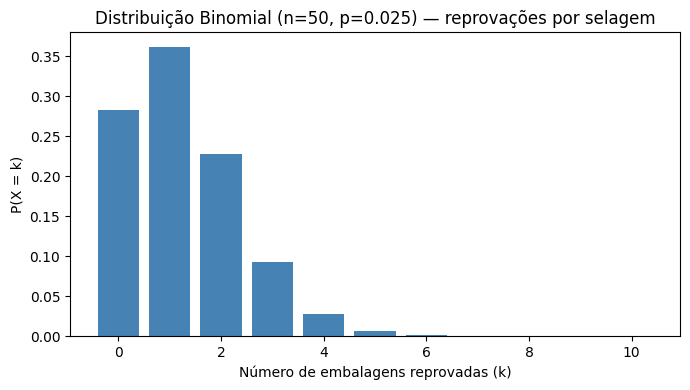

In [ ]:
# Modelo Binomial: número de embalagens reprovadas em uma amostra de n = 50
n = 50
p_reprovada = 0.025  # mesma referência AQL de 2,5% (ISO 2859-1) usada no exemplo de Bernoulli

binom_rv = stats.binom(n, p_reprovada)

# Simulação de uma amostra real de inspeção
amostra_simulada = binom_rv.rvs(size=1, random_state=1)[0]
print(f"Simulação de UMA amostra de {n} embalagens: {amostra_simulada} reprovadas\n")

# Distribuição de probabilidade teórica (PMF) para k = 0 até 10 reprovações
k_valores = np.arange(0, 11)
probabilidades = binom_rv.pmf(k_valores)

tabela_binom = pd.DataFrame({"nº de embalagens reprovadas (k)": k_valores,
                              "P(X = k)": np.round(probabilidades, 5)})
print(tabela_binom.to_string(index=False))

print(f"\nMédia teórica E[X] = n*p = {binom_rv.mean():.3f} embalagens reprovadas")
print(f"Desvio-padrão teórico = {binom_rv.std():.3f}")
print(f"P(X = 0) [nenhuma reprovada] = {binom_rv.pmf(0):.4f}")
print(f"P(X >= 3) [3 ou mais reprovadas] = {1 - binom_rv.cdf(2):.4f}")

# Gráfico da distribuição
plt.bar(k_valores, probabilidades, color="steelblue")
plt.xlabel("Número de embalagens reprovadas (k)")
plt.ylabel("P(X = k)")
plt.title(f"Distribuição Binomial (n={n}, p={p_reprovada}) — reprovações por selagem")
plt.tight_layout()
plt.show()

**Interpretação:** em média, espera-se $E[X] = n \cdot p = 50 \times 0{,}025 = 1{,}25$
embalagens reprovadas a cada amostra de 50. A probabilidade de que a amostra não apresente nenhuma
reprovação é de aproximadamente 28%, enquanto a probabilidade de encontrar 3 ou mais embalagens
reprovadas — o que indicaria possível desvio no processo de selagem — é relativamente baixa,
mas não desprezível. Esse tipo de cálculo é a base dos planos de amostragem de aceitação usados
no controle de qualidade industrial (ISO 2859-1).

## 5. Modelo de Poisson

O modelo de **Poisson** representa a **contagem do número de ocorrências de um evento** em um
intervalo fixo de **tempo, espaço, área, volume ou unidade de produção**, quando os eventos ocorrem
de forma aleatória e independente, a uma taxa média constante $\lambda$ (ROSS, 2010).

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \qquad k = 0, 1, 2, \dots$$

O modelo de Poisson é amplamente utilizado em **cartas de controle de atributos do tipo "c" e "u"**
para monitorar o número de defeitos por unidade de produto ou por unidade de área/tempo em
processos contínuos de produção, como linhas de envase (ISEG, 2019).

**Exemplo aplicado:** o número de **falhas de envase** (ex.: embalagens mal fechadas, sub ou
sobre-enchidas) registradas por **hora** em uma linha de envase de sucos. Com base em um histórico
de operação da linha, adota-se uma taxa média de referência $\lambda = 3$ falhas por hora
(valor ilustrativo, definido a partir do histórico simulado do processo).

Simulação de falhas registradas em cada uma das 8 horas do turno:
[2 4 4 1 4 5 4 3]
Total de falhas no turno de 8h: 27

 nº de falhas por hora (k)  P(X = k)
                         0   0.04979
                         1   0.14936
                         2   0.22404
                         3   0.22404
                         4   0.16803
                         5   0.10082
                         6   0.05041
                         7   0.02160
                         8   0.00810
                         9   0.00270
                        10   0.00081

Média teórica E[X] = lambda = 3.000 falhas/hora
P(X = 0) [nenhuma falha na hora] = 0.0498
P(X > 5) [mais de 5 falhas na hora] = 0.0839


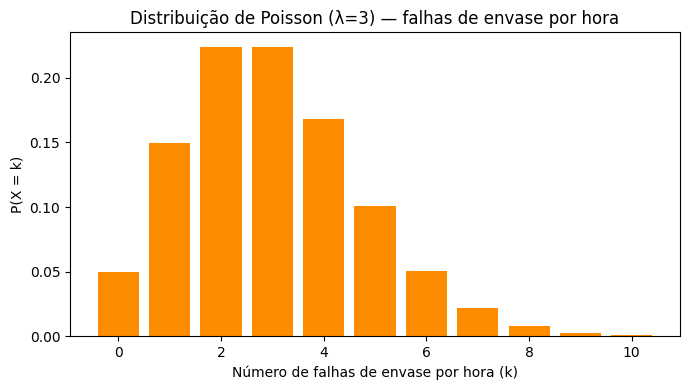

In [ ]:
# Modelo de Poisson: número de falhas de envase por hora em uma linha de produção
lam = 3  # taxa média de falhas por hora (lambda)

poisson_rv = stats.poisson(lam)

# Simulação de um turno de 8 horas
falhas_por_hora = poisson_rv.rvs(size=8, random_state=7)
print("Simulação de falhas registradas em cada uma das 8 horas do turno:")
print(falhas_por_hora)
print(f"Total de falhas no turno de 8h: {falhas_por_hora.sum()}\n")

# Distribuição de probabilidade teórica (PMF)
k_valores = np.arange(0, 11)
probabilidades = poisson_rv.pmf(k_valores)

tabela_poisson = pd.DataFrame({"nº de falhas por hora (k)": k_valores,
                                "P(X = k)": np.round(probabilidades, 5)})
print(tabela_poisson.to_string(index=False))

print(f"\nMédia teórica E[X] = lambda = {poisson_rv.mean():.3f} falhas/hora")
print(f"P(X = 0) [nenhuma falha na hora] = {poisson_rv.pmf(0):.4f}")
print(f"P(X > 5) [mais de 5 falhas na hora] = {1 - poisson_rv.cdf(5):.4f}")

plt.bar(k_valores, probabilidades, color="darkorange")
plt.xlabel("Número de falhas de envase por hora (k)")
plt.ylabel("P(X = k)")
plt.title(f"Distribuição de Poisson (λ={lam}) — falhas de envase por hora")
plt.tight_layout()
plt.show()

**Interpretação:** com $\lambda = 3$ falhas/hora, a probabilidade de uma hora transcorrer
sem nenhuma falha de envase é de aproximadamente 5%, enquanto a chance de ocorrerem mais de 5 falhas
em uma única hora — o que sinalizaria a necessidade de parada para ajuste da máquina — é de cerca de
8%. Esse tipo de monitoramento é a base das cartas de controle "c" usadas em controle estatístico
de processos na indústria de alimentos.

## 6. Comparação entre os modelos de Bernoulli, Binomial e Poisson

In [ ]:
comparacao = pd.DataFrame({
    "Modelo": ["Bernoulli", "Binomial", "Poisson"],
    "Tipo de fenômeno representado": [
        "Um único ensaio com dois resultados possíveis (sucesso/fracasso)",
        "Número de sucessos em um número FIXO de ensaios de Bernoulli independentes",
        "Número de ocorrências de um evento em um intervalo de tempo/espaço/volume"
    ],
    "Valores possíveis de X": [
        "{0, 1}",
        "{0, 1, 2, ..., n}",
        "{0, 1, 2, 3, ...} (sem limite superior definido)"
    ],
    "Quando aplicar": [
        "Uma única observação com resultado binário",
        "n observações fixas, mesma p, resultado binário em cada uma",
        "Contagem de eventos raros/aleatórios em um intervalo contínuo"
    ],
    "Exemplo em Ciências dos Alimentos": [
        "Uma embalagem é aprovada ou reprovada na inspeção de selagem",
        "Nº de embalagens reprovadas em uma amostra de 50 unidades",
        "Nº de falhas de envase registradas por hora na linha de produção"
    ]
})

pd.set_option("display.max_colwidth", None)
print(comparacao.to_string(index=False))

   Modelo                                              Tipo de fenômeno representado                           Valores possíveis de X                                                Quando aplicar                                Exemplo em Ciências dos Alimentos
Bernoulli           Um único ensaio com dois resultados possíveis (sucesso/fracasso)                                           {0, 1}                    Uma única observação com resultado binário     Uma embalagem é aprovada ou reprovada na inspeção de selagem
 Binomial Número de sucessos em um número FIXO de ensaios de Bernoulli independentes                                {0, 1, 2, ..., n}   n observações fixas, mesma p, resultado binário em cada uma        Nº de embalagens reprovadas em uma amostra de 50 unidades
  Poisson  Número de ocorrências de um evento em um intervalo de tempo/espaço/volume {0, 1, 2, 3, ...} (sem limite superior definido) Contagem de eventos raros/aleatórios em um intervalo contínuo Nº de falhas de envas

**Síntese:**
- O modelo de **Bernoulli** é o caso mais simples — um único ensaio binário — e serve de base
  conceitual para os outros dois modelos.
- O modelo **Binomial** surge quando repetimos $n$ ensaios de Bernoulli idênticos e independentes e
  contamos o número total de sucessos; é adequado para controle de qualidade por **amostragem de
  lotes** (n fixo).
- O modelo de **Poisson** é usado quando o interesse está na **contagem de eventos raros** ao longo
  de um intervalo contínuo (tempo, área, volume), sem um número fixo de "tentativas" definido — como
  no monitoramento contínuo de falhas em uma linha de produção. Na prática, o Poisson também pode
  ser usado como aproximação da Binomial quando $n$ é grande e $p$ é pequeno (MONTGOMERY; RUNGER, 2018).

## 7. Referências

**Bibliográficas:**

- MAGALHÃES, Marcos Nascimento; LIMA, Antonio Carlos Pedroso de. *Noções de Probabilidade e
  Estatística*. 7. ed. São Paulo: Edusp, 2015.
- MONTGOMERY, Douglas C.; RUNGER, George C. *Estatística Aplicada e Probabilidade para
  Engenheiros*. 7. ed. Rio de Janeiro: LTC, 2018.
- ROSS, Sheldon. *A First Course in Probability*. 9. ed. Boston: Pearson, 2010.

**Fontes técnicas consultadas (parâmetros de referência dos exemplos):**

- ISO 2859-1 — *Sampling procedures for inspection by attributes*, citada em: GUELCOS. **O que é
  AQL e como funciona o controle de qualidade dos produtos importados**. Disponível em:
  https://guelcos.com.br/conteudo/o-que-e-aql-e-como-funciona-o-controle-de-qualidade-dos-produtos-importados.
  Acesso em: 27 set. 2026.
- ISIXSIGMA. **Acceptable Quality Level (AQL)**. Disponível em:
  https://isixsigma.com/?p=205401. Acesso em: 27 set. 2026.
- ISEG — Instituto Superior de Economia e Gestão (Universidade de Lisboa). **Diferenças entre os
  Gráficos de Atributos (p, np, c, u)**. Disponível em:
  https://fenix.iseg.ulisboa.pt/downloadFile/281608120740418/Diferencas%20entre%20os%20Graficos%20de%20Atributos.pdf.
  Acesso em: 27 set. 2026.

**Observação sobre os dados:** os valores numéricos utilizados nas simulações (percentuais de dano
em frutas, massas de embalagens, taxa de falhas por hora) são **dados simulados**, gerados no
próprio notebook com `numpy.random`, e não dados reais coletados de uma linha de produção
específica. Os parâmetros $p$ e $\lambda$ foram escolhidos com base em valores de referência da
literatura de controle de qualidade (AQL de 2,5% da ISO 2859-1) e em faixas plausíveis relatadas
para perdas pós-colheita de frutas, conforme indicado em cada seção.